# 물리화학 1 — Focus 1 기체의 성질: Google Colab 계산·시각화 실습




##  Colab 준비
아래 셀을 먼저 실행하세요. 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import pi
from scipy.optimize import brentq
from scipy.integrate import quad
from IPython.display import display, Markdown

try:
    import ipywidgets as widgets
    from ipywidgets import interact, interactive, fixed
    try:
        from google.colab import output
        output.enable_custom_widget_manager()
    except Exception:
        pass
    WIDGETS_OK = True
except Exception:
    WIDGETS_OK = False

# SI constants
R = 8.31446261815324       # J mol^-1 K^-1
kB = 1.380649e-23          # J K^-1
NA = 6.02214076e23         # mol^-1
R_L_atm = 0.08205736608096 # L atm mol^-1 K^-1
ATM_PA = 101325.0
BAR_PA = 1e5

# collision cross section, nm^2
collision_sigma_nm2 = {
    'C2H4': 0.88,
    'CO2': 0.52,
    'He': 0.21,
    'N2': 0.43,
}

# Molar masses (g/mol): 표준 화학식량을 사용한 보조 데이터
molar_mass_gmol = {
    'He': 4.0026,
    'N2': 28.0134,
    'CO2': 44.0095,
    'Xe': 131.293,
    'C2H4': 28.0532,
    'Ar': 39.948,
}

# Table 1C.3: a [atm dm^6 mol^-2], b column is 10^-2 dm^3 mol^-1
vdw = {
    'Ar':  {'a': 1.337,  'b': 3.20e-2},
    'CO2': {'a': 3.610,  'b': 4.29e-2},
    'He':  {'a': 0.0341, 'b': 2.38e-2},
    'Xe':  {'a': 4.137,  'b': 5.16e-2},
}

# Table 1C.1: B [cm^3 mol^-1]
virial_B = pd.DataFrame({
    'gas': ['Ar', 'CO2', 'N2', 'Xe'],
    '273 K': [-21.7, -14.2, -10.5, -153.7],
    '600 K': [11.9, -12.4, 21.7, -19.6],
}).set_index('gas')

print('준비 완료')
print(f'R = {R:.6f} J mol^-1 K^-1,  kB = {kB:.6e} J K^-1')


준비 완료
R = 8.314463 J mol^-1 K^-1,  kB = 1.380649e-23 J K^-1


# Project 1. 상태 변수 $p,V,T,n$ — “기체의 상태를 숫자로 표현하기”


완전기체의 상태는 네 변수로 표현할 수 있습니다.

$$pV=nRT$$

네 변수 중 세 개가 정해지면 나머지 하나가 결정됩니다.

### 개념 체크
- 압력 $p$: 단위 면적당 힘, $p=F/A$
- 부피 $V$: 기체가 차지하는 공간
- 열역학적 온도 $T$: Kelvin 척도
- 물질량 $n$: mol

### 세기/크기 성질 사고실험
용기를 정확히 절반으로 나누면:
- $T$, $p$는 그대로 → **세기(intensive)**
- $V$, $n$, 질량은 절반 → **크기(extensive)**


In [2]:
def ideal_gas_state(p_bar=1.0, T_K=298.15, n_mol=1.0):
    p = p_bar * BAR_PA
    V_m3 = n_mol * R * T_K / p
    V_L = 1000 * V_m3
    print(f'p = {p_bar:.3f} bar')
    print(f'T = {T_K:.2f} K')
    print(f'n = {n_mol:.3f} mol')
    print(f'V = {V_L:.3f} L')
    print(f'molar volume = {V_L/n_mol:.3f} L/mol')

if WIDGETS_OK:
    interact(ideal_gas_state,
             p_bar=widgets.FloatSlider(value=1.0, min=0.2, max=10, step=0.2, description='p / bar'),
             T_K=widgets.FloatSlider(value=298.15, min=100, max=800, step=10, description='T / K'),
             n_mol=widgets.FloatSlider(value=1.0, min=0.1, max=5, step=0.1, description='n / mol'));
else:
    ideal_gas_state()


p = 1.000 bar
T = 298.15 K
n = 1.000 mol
V = 24.790 L
molar volume = 24.790 L/mol


1. $T,n$을 고정하고 압력을 1 bar → 2 bar로 바꾸세요. $V$는 몇 배가 됩니까?
2. $p,n$을 고정하고 온도를 300 K → 600 K로 바꾸세요. $V$는 몇 배가 됩니까?
3. $p,T$를 고정하고 $n$을 1 mol → 2 mol로 바꾸세요.


# Boyle 법칙 — $p\propto 1/V$

> **PPT 연계:** p.4, 그림 1A.2–1A.3

$T,n$ 일정일 때

$$pV=\text{constant}$$

따라서

$$p\propto \frac{1}{V}$$

슬라이드의 두 그림을 그대로 재현해 봅니다: $p$–$V$에서는 곡선, $p$–$1/V$에서는 직선입니다.


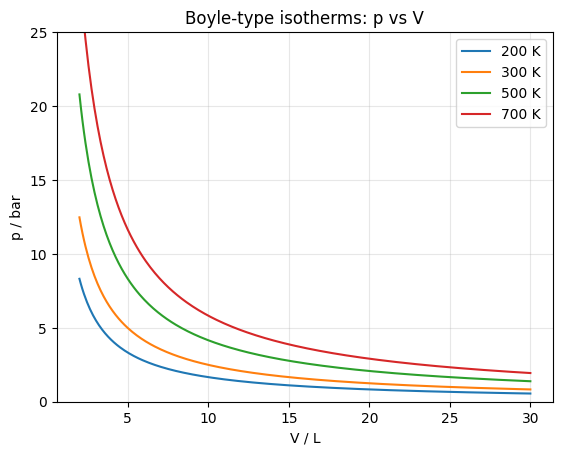

In [3]:
n = 1.0
V_L = np.linspace(2, 30, 300)
V_m3 = V_L / 1000
for T in [200, 300, 500, 700]:
    p_bar = n * R * T / V_m3 / BAR_PA
    plt.plot(V_L, p_bar, label=f'{T} K')
plt.xlabel('V / L')
plt.ylabel('p / bar')
plt.title('Boyle-type isotherms: p vs V')
plt.ylim(0, 25)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


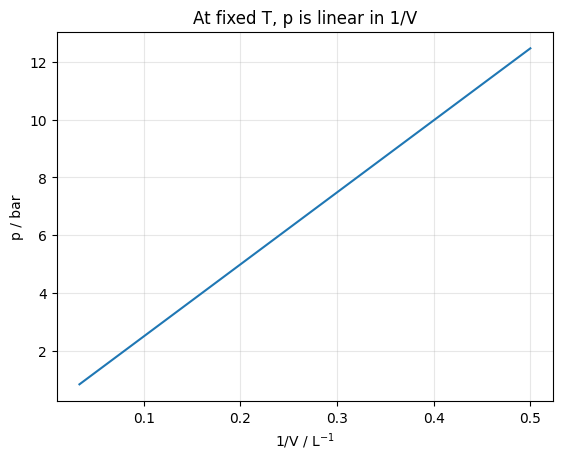

직선 기울기 ≈ 24.943 bar·L
이론값 nRT ≈ 24.943 bar·L


In [4]:
T = 300
p_bar = n * R * T / V_m3 / BAR_PA
invV = 1 / V_L
plt.plot(invV, p_bar)
plt.xlabel('1/V / L$^{-1}$')
plt.ylabel('p / bar')
plt.title('At fixed T, p is linear in 1/V')
plt.grid(alpha=0.3)
plt.show()

coef = np.polyfit(invV, p_bar, 1)
print(f'직선 기울기 ≈ {coef[0]:.3f} bar·L')
print(f'이론값 nRT ≈ {n*R*T/100:.3f} bar·L')


#  완전기체의 $p$–$V$–$T$ 상태면

> **PPT 연계:** p.5, 그림 1A.6

완전기체는 임의의 $(p,V,T)$를 가질 수 있는 것이 아니라

$$p=\frac{nRT}{V}$$

을 만족하는 **상태면(surface)** 위에 존재합니다.


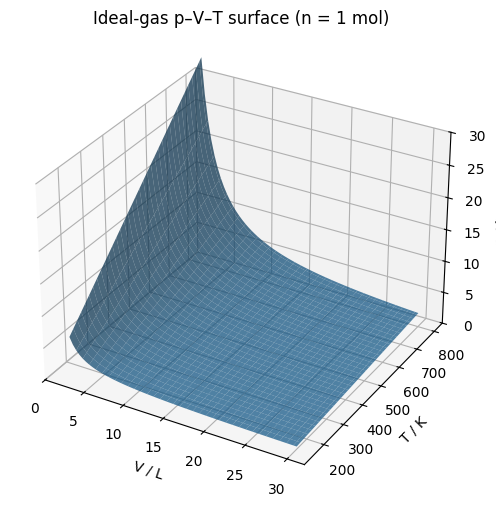

In [7]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
n = 1.0
V_L = np.linspace(2, 30, 70)
T_K = np.linspace(150, 800, 70)
VV, TT = np.meshgrid(V_L, T_K)
PP_bar = n*R*TT/(VV/1000)/BAR_PA

fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(VV, TT, PP_bar, alpha=0.75, linewidth=0)
ax.set_xlabel('V / L')
ax.set_ylabel('T / K')
ax.set_zlabel('p / bar')
ax.set_zlim(0, 30)
ax.set_title('Ideal-gas p–V–T surface (n = 1 mol)')
plt.show()


#  표준조건과 몰부피

> **PPT 연계:** p.6

슬라이드에는 두 조건이 구분되어 있습니다.

- 298.15 K, 1 bar → 완전기체 $V_m\approx24.789\ \mathrm{dm^3\ mol^{-1}}$
- 0 °C, 1 atm → 완전기체 $V_m\approx22.414\ \mathrm{dm^3\ mol^{-1}}$

직접 계산해 확인합니다.


In [8]:
conditions = [
    ('298.15 K, 1 bar', 298.15, 1e5),
    ('273.15 K, 1 atm', 273.15, ATM_PA),
]
rows=[]
for name,T,p in conditions:
    Vm_L = R*T/p*1000
    rows.append([name, T, p, Vm_L])
display(pd.DataFrame(rows, columns=['condition','T/K','p/Pa','Vm/(L mol^-1)']))


,condition,T/K,p/Pa,Vm/(L mol^-1)
0,"298.15 K, 1 bar",298.15,100000.0,24.78957
1,"273.15 K, 1 atm",273.15,101325.0,22.41397


# 분자 운동론 — 거시적 압력을 미시적 속도로부터 얻기

> **PPT 연계:** p.8–9

분자 운동론의 핵심 결과:

$$pV=\frac13 nM\langle v^2\rangle$$

또한 완전기체에서

$$\langle v^2\rangle=\frac{3RT}{M}$$

이 둘을 결합하면 $pV=nRT$가 됩니다.

### Monte Carlo 아이디어
열평형에서 각 속도 성분을 정규분포에서 샘플링하고, 표본 평균 $\langle v^2\rangle$가 이론값에 가까워지는지 봅니다.


통계역학에 따르면, 열평형 상태에 있는 기체 분자의 각 독립적인 운동 에너지 자유도(degree of freedom)당 평균 에너지는 $\frac{1}{2}k_B T$입니다.분자의 $x$ 방향 운동 에너지는 다음과 같습니다:$$E_k = \frac{1}{2} m v_x^2$$이 에너지의 통계적 평균값은 에너지 등분배 정리에 의해 다음과 같이 주어집니다:$$\left\langle \frac{1}{2} m v_x^2 \right\rangle = \frac{1}{2} k_B T$$양변에서 질량 $m$과 상수를 정리하면 속력 제곱의 평균이 나옵니다:$$\langle v_x^2 \rangle = \frac{k_B T}{m}$$이때 기체 분자는 어느 한쪽 방향으로 치우쳐 이동하지 않으므로 속도의 평균값은 0 ($\langle v_x \rangle = 0$)입니다. 따라서 분산의 정의에 따라 다음과 같이 됩니다:$$\text{Var}(v_x) = \langle v_x^2 \rangle - \langle v_x \rangle^2 = \langle v_x^2 \rangle - 0 = \frac{k_B T}{m}$$

또는 맥스웰-볼츠만 분포에 따르면, 기체 분자의 특정 속도 성분($v_x$)이 가질 확률 밀도 함수 $f(v_x)$는 평균이 0인 정규분포(가우스 분포) 형태를 가집니다.$$f(v_x) = \left(\frac{m}{2\pi k_B T}\right)^{1/2} \exp\left(-\frac{m v_x^2}{2 k_B T}\right)$$일반적인 정규분포 확률밀도 함수 $\mathcal{N}(0, \sigma^2)$의 수식은 다음과 같습니다:$$f(x) = \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left(-\frac{x^2}{2\sigma^2}\right)$$두 식을 비교해 보면 지수함수 내부의 분모를 통해 분산 $\sigma^2$을 곧바로 찾을 수 있습니다.$$\frac{1}{2\sigma^2} = \frac{m}{2k_B T} \implies \sigma^2 = \frac{k_B T}{m}$$

In [10]:
def kinetic_monte_carlo(gas='N2', T=298.15, Nsample=100_000, seed=1):
    M = molar_mass_gmol[gas] / 1000  # kg/mol
    m = M / NA                       # kg/molecule
    sigma_v = np.sqrt(kB*T/m)        # each Cartesian component std
    rng = np.random.default_rng(seed)
    vx = rng.normal(0, sigma_v, Nsample)
    vy = rng.normal(0, sigma_v, Nsample)
    vz = rng.normal(0, sigma_v, Nsample)
    v2 = vx**2 + vy**2 + vz**2
    mc = v2.mean()
    theory = 3*R*T/M
    print(f'{gas}, T={T:.1f} K, samples={Nsample:,}')
    print(f'Monte Carlo <v^2> = {mc:,.1f} m^2/s^2')
    print(f'Theory      <v^2> = {theory:,.1f} m^2/s^2')
    print(f'ratio MC/theory   = {mc/theory:.5f}')
    print(f'<vx^2>:<vy^2>:<vz^2> = {np.mean(vx**2):.1f}:{np.mean(vy**2):.1f}:{np.mean(vz**2):.1f}')

kinetic_monte_carlo('N2', 298.15)


N2, T=298.1 K, samples=100,000
Monte Carlo <v^2> = 264,750.4 m^2/s^2
Theory      <v^2> = 265,475.5 m^2/s^2
ratio MC/theory   = 0.99727
<vx^2>:<vy^2>:<vz^2> = 87881.2:88672.2:88197.0


- `Nsample`을 $10^2$, $10^3$, $10^5$로 바꿔보세요.
- 표본 수가 증가할수록 이론값에 어떻게 접근합니까?
- $\langle v_x^2\rangle$, $\langle v_y^2\rangle$, $\langle v_z^2\rangle$가 비슷해지는 이유를 “무작위 운동”과 연결하세요.


# Maxwell–Boltzmann 속력분포

> **PPT 연계:** p.10–12

$$f(v)=4\pi\left(\frac{M}{2\pi RT}\right)^{3/2}v^2\exp\left(-\frac{Mv^2}{2RT}\right)$$

핵심 관찰:
- $T$ 증가 → 분포가 넓어지고 빠른 분자 증가
- $M$ 증가 → 같은 온도에서 더 느린 쪽으로 이동
- $v=0$에서도 분율은 0에 접근하고, 아주 큰 $v$에서도 0에 접근


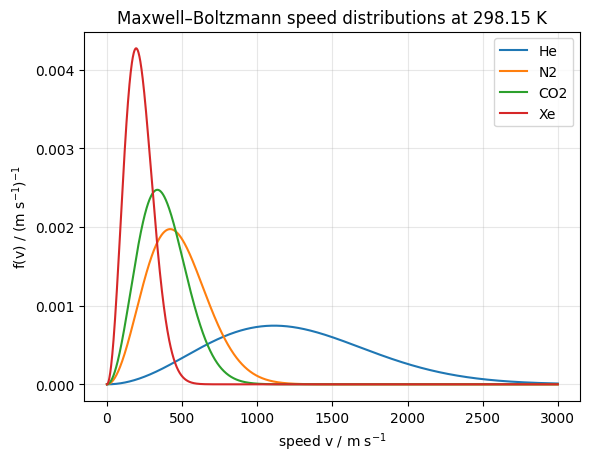

In [11]:
def maxwell_speed_pdf(v, M_kgmol, T):
    return 4*np.pi*(M_kgmol/(2*np.pi*R*T))**1.5 * v**2 * np.exp(-M_kgmol*v**2/(2*R*T))

v = np.linspace(0, 3000, 1500)
T = 298.15
for gas in ['He','N2','CO2','Xe']:
    M=molar_mass_gmol[gas]/1000
    plt.plot(v, maxwell_speed_pdf(v,M,T), label=gas)
plt.xlabel('speed v / m s$^{-1}$')
plt.ylabel('f(v) / (m s$^{-1}$)$^{-1}$')
plt.title('Maxwell–Boltzmann speed distributions at 298.15 K')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


#  Maxwell–Boltzmann 실험

> **PPT 연계:** p.12, 그림 1B.4

슬라이더를 움직이며 **봉우리의 위치, 높이, 폭** 세 가지를 관찰하세요.


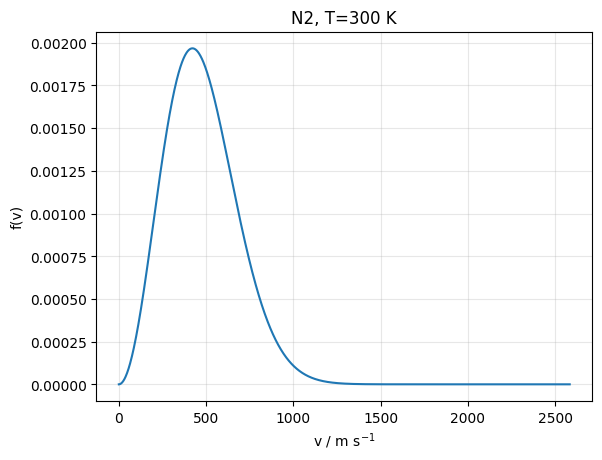

v_mp   = 422.0 m/s
v_mean = 476.2 m/s
v_rms  = 516.8 m/s


In [12]:
def mb_interactive(gas='N2', T=300):
    M = molar_mass_gmol[gas]/1000
    vmax = max(1500, 5*np.sqrt(3*R*T/M))
    v=np.linspace(0,vmax,1200)
    f=maxwell_speed_pdf(v,M,T)
    plt.plot(v,f)
    plt.xlabel('v / m s$^{-1}$')
    plt.ylabel('f(v)')
    plt.title(f'{gas}, T={T} K')
    plt.grid(alpha=0.3)
    plt.show()

    v_mp=np.sqrt(2*R*T/M)
    v_mean=np.sqrt(8*R*T/(np.pi*M))
    v_rms=np.sqrt(3*R*T/M)
    print(f'v_mp   = {v_mp:.1f} m/s')
    print(f'v_mean = {v_mean:.1f} m/s')
    print(f'v_rms  = {v_rms:.1f} m/s')

if WIDGETS_OK:
    interact(mb_interactive,
             gas=widgets.Dropdown(options=['He','N2','CO2','Xe'], value='N2'),
             T=widgets.IntSlider(value=300,min=100,max=1200,step=25));
else:
    mb_interactive()


# 최빈속력, 평균속력, RMS 속력

> **PPT 연계:** p.13–14

$$v_{mp}=\sqrt{\frac{2RT}{M}}$$

$$\bar v=\sqrt{\frac{8RT}{\pi M}}$$

$$v_{rms}=\sqrt{\frac{3RT}{M}}$$

비대칭 분포이므로 세 값은 같지 않습니다.

$$v_{mp}<\bar v<v_{rms}$$

최빈속력 ($v_{mp} = \sqrt{\frac{2RT}{M}}$): 가장 많은 분자들이 가지고 있는 속력으로, 분포의 꼭대기(최댓값)에 해당합니다.

평균속력 ($\bar{v} = \sqrt{\frac{8RT}{\pi M}}$): 모든 분자 속력의 산술 평균이며, 비대칭 꼬리의 영향으로 최빈속력보다 약간 오른쪽(고속 쪽)에 위치합니다.

RMS 속력 ($v_{rms} = \sqrt{\frac{3RT}{M}}$): 속력 제곱 평균의 제곱근으로, 분자의 평균 운동에너지를 직접적으로 대변하며 가장 큰 값을 가집니다.

In [13]:
def speed_summary(T=298.15):
    rows=[]
    for gas in ['He','N2','CO2','Xe']:
        M=molar_mass_gmol[gas]/1000
        vmp=np.sqrt(2*R*T/M)
        vmean=np.sqrt(8*R*T/(np.pi*M))
        vrms=np.sqrt(3*R*T/M)
        rows.append([gas,M*1000,vmp,vmean,vrms])
    return pd.DataFrame(rows, columns=['gas','M/g mol^-1','v_mp/m s^-1','v_mean/m s^-1','v_rms/m s^-1'])

display(speed_summary())


,gas,M/g mol^-1,v_mp/m s^-1,v_mean/m s^-1,v_rms/m s^-1
0,He,4.0026,1112.957042,1255.837540,1363.088429
1,N2,28.0134,420.694259,474.702638,515.243137
2,CO2,44.0095,335.641984,378.731423,411.075799
3,Xe,131.2930,194.325016,219.272299,237.998566


$$v_{rms}=\sqrt{\frac{3RT}{M}}$$

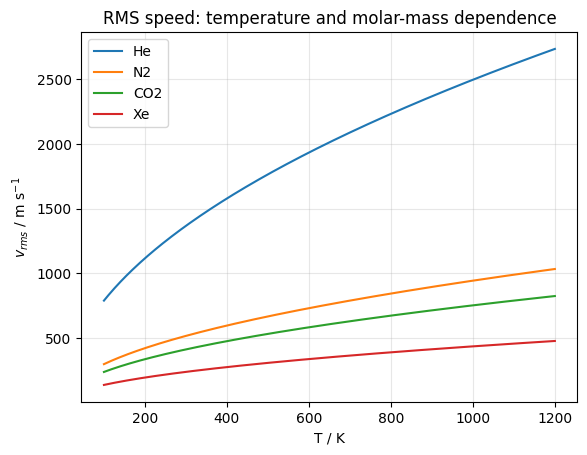

In [14]:
temps=np.linspace(100,1200,300)
for gas in ['He','N2','CO2','Xe']:
    M=molar_mass_gmol[gas]/1000
    vrms=np.sqrt(3*R*temps/M)
    plt.plot(temps,vrms,label=gas)
plt.xlabel('T / K')
plt.ylabel('$v_{rms}$ / m s$^{-1}$')
plt.title('RMS speed: temperature and molar-mass dependence')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 충돌빈도와 평균 자유 행로

> **PPT 연계:** p.15–17

슬라이드의 정의를 따르면

$$z=\sigma v_{rel}\frac{p}{k_BT}$$

$$\lambda=\frac{v_{rel}}{z}=\frac{k_BT}{\sigma p}$$

여기서 $\sigma$는 충돌 단면적입니다.

> p.16의 $N_2$ 계산은 $z\sim 10^9\ \mathrm{s^{-1}}$입니다. 그러면 충돌 사이 시간 $\tau=1/z$는 ms가 아니라 훨씬 짧습니다. 실제로 계산해봅시다.


충돌 단면적 (sigma): sigma = collision_sigma_nm2[gas]*1e-18을 통해 $\text{nm}^2$ 단위를 $\text{m}^2$ 단위로 변환합니다. 

($4.3 \times 10^{-19}\text{ m}^2$)상대 속도 (v_rel): 평균 분자 속력($v_{mean}$)에 $\sqrt{2}$를 곱하여 두 분자 간의 평균 상대 속력($v_{rel} = \sqrt{2} \bar{v}$)을 구합니다. 

($671.3\text{ m/s}$)수밀도 (number_density): 이상기체 법칙($pV = nRT$ 또는 $p = nk_BT$)을 변형하여 단위 부피당 분자 수($n = p / k_B T$)를 계산합니다. 

상온·상압에서 약 $2.46 \times 10^{25}\text{ m}^{-3}$의 엄청난 분자가 존재함을 보여줍니다.

충돌 빈도 (z):$$z = \sigma \cdot v_{rel} \cdot n$$단일 분자가 단위 시간당 겪는 충돌 횟수이며, 계산 결과 약 $7.11 \times 10^9\text{ s}^{-1}$ (초당 약 71억 번)으로  언급된 수치와 일치합니다.

In [15]:
def collision_properties(gas='N2', T=298.15, p_atm=1.0):
    sigma = collision_sigma_nm2[gas]*1e-18  # nm^2 -> m^2
    M = molar_mass_gmol[gas]/1000
    v_mean=np.sqrt(8*R*T/(np.pi*M))
    v_rel=np.sqrt(2)*v_mean  # same-species mean relative speed, as in PPT N2 example
    p=p_atm*ATM_PA
    number_density=p/(kB*T)
    z=sigma*v_rel*number_density
    tau=1/z
    # PPT p.17 convention: lambda = v_rel/z
    lam=v_rel/z
    print(f'{gas}, T={T:.2f} K, p={p_atm:.2f} atm')
    print(f'sigma = {sigma:.3e} m^2')
    print(f'mean molecular speed = {v_mean:.1f} m/s')
    print(f'mean relative speed  = {v_rel:.1f} m/s')
    print(f'number density        = {number_density:.3e} m^-3')
    print(f'collision frequency z = {z:.3e} s^-1')
    print(f'time between collisions 1/z = {tau:.3e} s = {tau*1e9:.3f} ns')
    print(f'PPT-convention lambda = {lam:.3e} m = {lam*1e9:.1f} nm')

collision_properties('N2', 298.15, 1.0)


N2, T=298.15 K, p=1.00 atm
sigma = 4.300e-19 m^2
mean molecular speed = 474.7 m/s
mean relative speed  = 671.3 m/s
number density        = 2.461e+25 m^-3
collision frequency z = 7.106e+09 s^-1
time between collisions 1/z = 1.407e-10 s = 0.141 ns
PPT-convention lambda = 9.448e-08 m = 94.5 nm


In [16]:
def collision_interactive(gas='N2', T=300, p_atm=1.0):
    sigma = collision_sigma_nm2[gas]*1e-18
    M = molar_mass_gmol[gas]/1000
    vmean=np.sqrt(8*R*T/(np.pi*M))
    vrel=np.sqrt(2)*vmean
    p=p_atm*ATM_PA
    z=sigma*vrel*p/(kB*T)
    lam=kB*T/(sigma*p)
    print(f'z = {z:.3e} s^-1')
    print(f'lambda = {lam*1e9:.2f} nm')

if WIDGETS_OK:
    interact(collision_interactive,
             gas=widgets.Dropdown(options=list(collision_sigma_nm2.keys()),value='N2'),
             T=widgets.IntSlider(value=300,min=100,max=1000,step=25),
             p_atm=widgets.FloatLogSlider(value=1,min=-2,max=2,step=0.1,description='p/atm'));
else:
    collision_interactive()


z = 7.084e+09 s^-1
lambda = 95.06 nm


1. $T$ 일정에서 $p$를 0.1, 1, 10 atm으로 바꿔 $z$와 $\lambda$를 비교하세요.
2. 압력이 10배 증가할 때 $\lambda$가 몇 배가 되는지 확인하세요.


# 실제기체의 분자간 인력과 반발력 — 정성적 potential model

> **PPT 연계:** p.18, 그림 1C.1

슬라이드의 핵심은 거리 변화에 따른 세 영역입니다.

- 아주 먼 거리: 상호작용 거의 0
- 중간 거리: 인력 우세
- 매우 짧은 거리: 반발력 급증

아래는 **슬라이드의 개념을 시각화하기 위한 보조 모델**인 reduced Lennard–Jones 형태입니다. 슬라이드가 특정 함수식을 제시한 것은 아니므로, 이 코드는 정성적 이해용입니다.

$$U^*(r^*)=4\left[(1/r^*)^{12}-(1/r^*)^6\right]$$


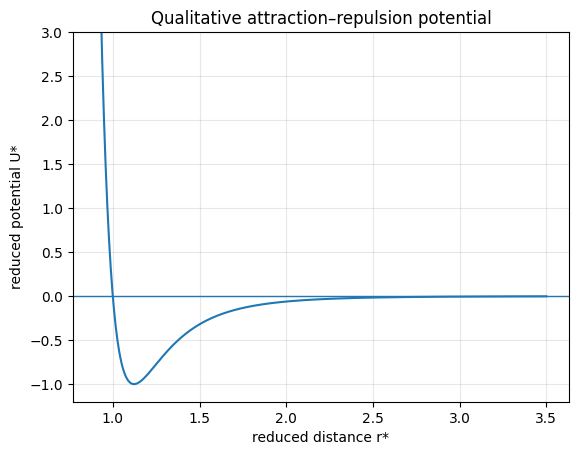

potential minimum at r* = 2^(1/6) = 1.122


In [17]:
r=np.linspace(0.9,3.5,800)
U=4*((1/r)**12-(1/r)**6)
F=24*(2/r**13-1/r**7)  # reduced radial force sign convention
plt.axhline(0,linewidth=1)
plt.plot(r,U)
plt.ylim(-1.2,3)
plt.xlabel('reduced distance r*')
plt.ylabel('reduced potential U*')
plt.title('Qualitative attraction–repulsion potential')
plt.grid(alpha=0.3)
plt.show()

rmin=2**(1/6)
print(f'potential minimum at r* = 2^(1/6) = {rmin:.3f}')


F = 24*(2/r**13 - 1/r**7)은 퍼텐셜 함수를 미분하여 얻은 힘($F = -\frac{dU}{dr}$)의 형태입니다. 힘이 0이 되는 지점(최소 퍼텐셜 위치)을 기준으로 안쪽에서는 척력(+), 바깥쪽에서는 인력(-)이 작용함을 정성적으로 보여줍니다

# van der Waals 방정식으로 실제기체 등온선 만들기

> **PPT 연계:** p.18–19, p.24, p.27

$$p=\frac{RT}{V_m-b}-\frac{a}{V_m^2}$$

- $a$: 인력 효과 → 압력을 낮추는 방향
- $b$: 배제부피 → 압력을 높이는 방향

PPT p.24의 $a,b$ 값을 사용합니다.


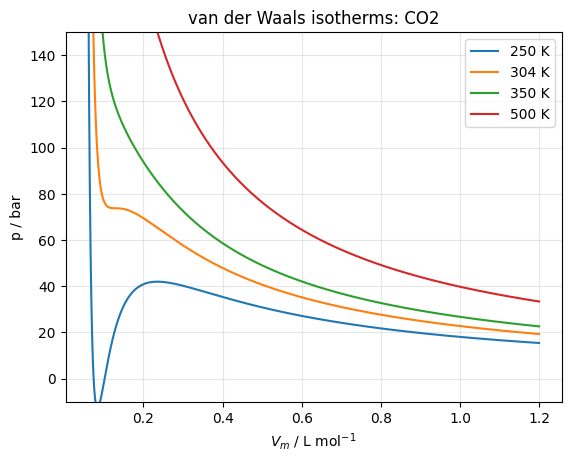

In [18]:
def vdw_p_bar(Vm_Lmol, T, gas):
    a=vdw[gas]['a']     # atm L^2 mol^-2 (dm^6 = L^2)
    b=vdw[gas]['b']     # L/mol
    p_atm=R_L_atm*T/(Vm_Lmol-b)-a/(Vm_Lmol**2)
    return p_atm*1.01325 # atm -> bar

def plot_vdw_isotherms(gas='CO2', temperatures=(250,304,350,500)):
    b=vdw[gas]['b']
    V=np.linspace(b*1.03,1.2,2500)
    for T in temperatures:
        p=vdw_p_bar(V,T,gas)
        mask=(p>-20)&(p<200)
        plt.plot(V[mask],p[mask],label=f'{T} K')
    plt.xlabel('$V_m$ / L mol$^{-1}$')
    plt.ylabel('p / bar')
    plt.title(f'van der Waals isotherms: {gas}')
    plt.ylim(-10,150)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_vdw_isotherms('CO2')


#  압축인자 $Z$ — “이상기체에서 얼마나 벗어났는가?”

> **PPT 연계:** p.20

$$Z=\frac{V_m}{V_m^\circ}=\frac{pV_m}{RT}$$

- $Z=1$: 완전기체
- $Z<1$: 인력 효과가 상대적으로 우세
- $Z>1$: 반발/배제부피 효과가 상대적으로 우세

van der Waals 방정식의 cubic root를 풀어 $V_m$과 $Z$를 계산합니다.


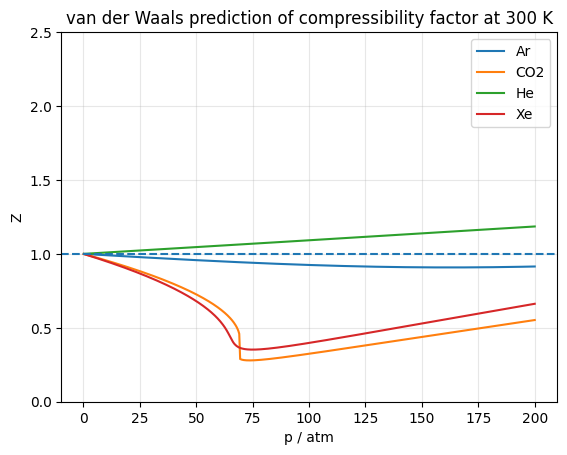

In [19]:
def vdw_molar_volume_roots_Lmol(gas, T, p_atm):
    a=vdw[gas]['a']; b=vdw[gas]['b']
    # p V^3 -(pb+RT)V^2 + aV - ab = 0
    coeff=[p_atm, -(p_atm*b+R_L_atm*T), a, -a*b]
    roots=np.roots(coeff)
    reals=sorted([x.real for x in roots if abs(x.imag)<1e-8 and x.real>b])
    return reals

def vdw_Z_gas_branch(gas,T,p_atm):
    roots=vdw_molar_volume_roots_Lmol(gas,T,p_atm)
    if not roots:
        return np.nan, np.nan
    Vm=max(roots)  # gas-like/largest-volume root
    Z=p_atm*Vm/(R_L_atm*T)
    return Z,Vm

pressures=np.linspace(0.2,200,500)
for gas in ['Ar','CO2','He','Xe']:
    Zs=[]
    for p in pressures:
        Z,_=vdw_Z_gas_branch(gas,300,p)
        Zs.append(Z)
    plt.plot(pressures,Zs,label=gas)
plt.axhline(1,linestyle='--')
plt.xlabel('p / atm')
plt.ylabel('Z')
plt.title('van der Waals prediction of compressibility factor at 300 K')
plt.ylim(0,2.5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


- CO$_2$에서 압력을 증가시키며 $Z<1$ 구간과 $Z>1$ 구간을 찾아보세요.
- He가 같은 온도에서 다른 경향을 보이는 이유를 p.24의 $a,b$와 연결해보세요.


# 비리알 상태방정식

> **PPT 연계:** p.21

몰부피 전개형:

$$pV_m=RT\left(1+\frac{B}{V_m}+\frac{C}{V_m^2}+\cdots\right)$$

낮은 밀도에서는 흔히 2차 비리알 계수 $B$가 가장 중요한 첫 보정이 됩니다.

아래 표는 **PPT p.21, Table 1C.1의 값**입니다.


In [20]:
display(virial_B)


,273 K,600 K
gas,,
Ar,-21.7,11.9
CO2,-14.2,-12.4
N2,-10.5,21.7
Xe,-153.7,-19.6


몰부피 전개형: $pV_m = RT \left(1 + \frac{B}{V_m} + \frac{C}{V_m^2} + \cdots\right)$압축 인자($Z$)와의 관계: 양변을 $RT로 나누면 $Z = 1 + \frac{B}{V_m} + \frac{C}{V_m^2} + \cdots$ 형태가 되므로, 낮은 밀도(큰 몰부피) 영역에서는 2차 비리알 계수 $B$가 이상기체로부터의 이탈을 결정하는 가장 중요한 첫 번째 보정 항이 됩니다.

$B$ 부호의 물리적 의미:$B < 0$: 분자 간 인력이 우세하여 이상기체보다 압축이 잘 되는 구간($Z < 1$)을 만듭니다. (예: $273\text{ K}$에서의 대부분의 기체들)

$B > 0$: 분자 간 반발력 및 배제 부피가 우세하여 부피가 덜 줄어드는 구간($Z > 1$)을 만듭니다. (예: 고온인 $600\text{ K}$에서의 $\text{Ar}$이나 $\text{N}_2$)

In [21]:
def virial_Z_from_B(gas='N2', T_label='273 K', Vm_Lmol=10.0):
    B_cm3=virial_B.loc[gas,T_label]
    B_L=B_cm3/1000
    Z=1+B_L/Vm_Lmol
    print(f'{gas}, {T_label}, B={B_cm3} cm^3/mol')
    print(f'Vm={Vm_Lmol:.3f} L/mol -> Z≈1+B/Vm={Z:.6f}')
    if Z<1: print('→ attractive correction direction (Z<1)')
    elif Z>1: print('→ repulsive/nonideal correction direction (Z>1)')
    else: print('→ ideal-like')

if WIDGETS_OK:
    interact(virial_Z_from_B,
             gas=widgets.Dropdown(options=virial_B.index.tolist(), value='N2'),
             T_label=widgets.Dropdown(options=['273 K','600 K'],value='273 K'),
             Vm_Lmol=widgets.FloatLogSlider(value=10,min=-1,max=2,step=0.1,description='Vm/L mol'));
else:
    virial_Z_from_B()


N2, 273 K, B=-10.5 cm^3/mol
Vm=10.000 L/mol -> Z≈1+B/Vm=0.998950
→ attractive correction direction (Z<1)


# Boyle 온도

보일 온도($T_B$)의 정의와 물리적 의미정의: 2차 비리알 계수 $B(T)$가 0이 되는 온도($B(T_B) = 0$)를 의미합니다.

이상기체적 거동:보일 온도에서는 분자 간 인력($a$에 의한 효과)과 배제 부피/반발력($b$에 의한 효과)이 서로 정확히 상쇄됩니다.

이 온도에서는 중저압 영역에서 기체가 이상기체 상태 방정식($pV_m \approx RT$)을 매우 오랫동안 정확하게 따르게 됩니다.

반데르발스 모델을 통한 유도와 해석근사식: 반데르발스 방정식을 낮은 밀도에서 전개하면 2차 비리알 계수가 $B(T) \approx b - \frac{a}{RT}$ 형태로 표현됩니다.

보일 온도 계산식: $B(T_B) = 0$이 되는 조건을 풀면 다음과 같은 관계식이 도출됩니다.$$T_B \approx \frac{a}{R b}$$


In [22]:
rows=[]
for gas,pars in vdw.items():
    TB=pars['a']/(R_L_atm*pars['b'])
    rows.append([gas,pars['a'],pars['b'],TB])
df_TB=pd.DataFrame(rows,columns=['gas','a/(atm L^2 mol^-2)','b/(L mol^-1)','vdW Boyle T / K'])
display(df_TB)


,gas,a/(atm L^2 mol^-2),b/(L mol^-1),vdW Boyle T / K
0,Ar,1.3370,0.0320,509.171230
1,CO2,3.6100,0.0429,1025.492142
2,He,0.0341,0.0238,17.460628
3,Xe,4.1370,0.0516,977.053279


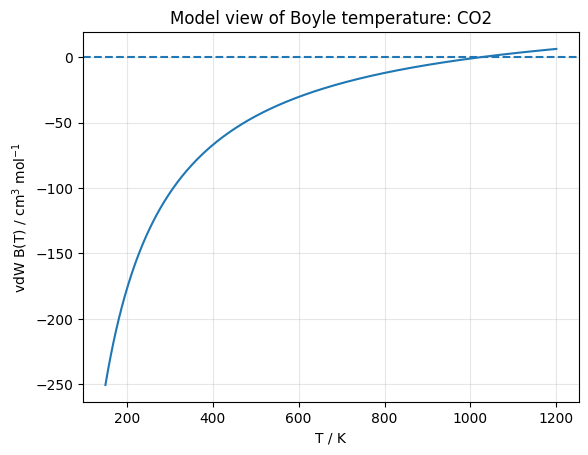

In [23]:
gas='CO2'
a=vdw[gas]['a']; b=vdw[gas]['b']
Tgrid=np.linspace(150,1200,500)
B_L=b-a/(R_L_atm*Tgrid)
plt.axhline(0,linestyle='--')
plt.plot(Tgrid,B_L*1000)
plt.xlabel('T / K')
plt.ylabel('vdW B(T) / cm$^3$ mol$^{-1}$')
plt.title('Model view of Boyle temperature: CO2')
plt.grid(alpha=0.3)
plt.show()


표에서 계산된 $\text{CO}_2$의 vdW 보일 온도는 약 $1025.5\text{ K}$입니다.하단의 그래프($\text{CO}_2$ 기준)를 보면 온도가 높아질수록 $B(T)$ 값이 음수(-)에서 증가하다가, 정확히 $1000\text{ K}$를 약간 웃도는 보일 온도 지점에서 $B(T) = 0$($\text{y축의 점선 만나는 지점}$)을 통과한 뒤 양수(+)로 전환되는 양상을 명확하게 보여줍니다.

# van der Waals 임계점

> **PPT 연계:** p.23, p.28

임계점에서 등온선은 변곡점을 가집니다.

$$\left(\frac{\partial p}{\partial V_m}\right)_T=0,\qquad
\left(\frac{\partial^2 p}{\partial V_m^2}\right)_T=0$$

van der Waals 식에서

$$V_c=3b,\qquad p_c=\frac{a}{27b^2},\qquad T_c=\frac{8a}{27Rb}$$

그리고

$$Z_c=\frac{p_cV_c}{RT_c}=\frac38$$


In [24]:
def vdw_critical(gas):
    a=vdw[gas]['a']; b=vdw[gas]['b']
    Vc=3*b
    pc=a/(27*b*b)
    Tc=8*a/(27*R_L_atm*b)
    Zc=pc*Vc/(R_L_atm*Tc)
    return Vc,pc,Tc,Zc

rows=[]
for gas in vdw:
    Vc,pc,Tc,Zc=vdw_critical(gas)
    rows.append([gas,Vc,pc,Tc,Zc])
display(pd.DataFrame(rows,columns=['gas','Vc/L mol^-1','pc/atm','Tc/K','Zc']))


,gas,Vc/L mol^-1,pc/atm,Tc/K,Zc
0,Ar,0.0960,48.357928,150.865550,0.375
1,CO2,0.1287,72.648868,303.849524,0.375
2,He,0.0714,2.229650,5.173519,0.375
3,Xe,0.1548,57.546956,289.497268,0.375


각 기체의 반데르발스 상수($a, b$)를 가져와 위의 유도식에 대입하여 $V_c, p_c, T_c, Z_c$를 계산합니다.

표 결과 확인: 아르곤($\text{Ar}$), 이산화탄소($\text{CO}_2$), 헬륨($\text{He}$), 제논($\text{Xe}$) 등 기체 종류에 따라 $a, b$ 값이 다르기 때문에 임계 부피($V_c$), 임계 압력($p_c$), 임계 온도($T_c$)는 제각각 다르게 나타납니다.

반면 맨 우측의 $Z_c$ 컬럼을 보면 모델의 특성상 모든 기체에서 0.375로 완벽하게 동일하게 출력

# CO$_2$의 “상태가 달라지는 것”을 직접 탐색하기

> **PPT 연계:** p.19, p.23, p.27–28

이 프로젝트는 “온도와 압력을 바꾸면 실제 물질의 상태가 어떻게 달라지는가?”를 보여주기 위한 **van der Waals + Maxwell 모델 실습**입니다.

주의: 이것은 정밀한 실제 CO$_2$ phase diagram 데이터베이스가 아니라, **PPT의 van der Waals 모델을 이용한 교육용 상태 분류**입니다.

분류 논리:
- 환산 온도($T_r = T / T_c$)와 환산 압력($p_r = p / p_c$)을 기준으로 물질의 상태를 크게 세 가지 영역으로 나눕니다.

- 초임계 영역 ($T_r > 1, p_r > 1$):온도와 압력이 모두 임계점보다 높은 상태로, 기체와 액체의 구분이 사라진 supercritical-like (초임계 유체 성상)로 분류합니다.

- 고온 기체 영역 ($T_r > 1, p_r < 1$):온도는 임계 온도보다 높지만 압력이 낮은 상태여서, 액화되지 않고 기체 상태로 존재하는 gas-like (above Tc)로 분류합니다.

- 저온 영역 ($T_r < 1$):임계 온도보다 낮은 상태이며, 맥스웰의 공존 압력($p_{sat}$) 계산값을 기준으로 판정합니다.

$p_r \approx p_{sat}$ 이면 two-phase coexistence boundary (기액 공존 경계면)$p_r < p_{sat}$ 이면 gas-like (기체 상태)$p_r > p_{sat}$ 이면 liquid-like (액체 상태)


In [27]:
def classify_vdw_state(gas='CO2', T_K=280.0, p_atm=50.0, tol=0.03):
    Vc,pc,Tc,Zc=vdw_critical(gas)
    Tr=T_K/Tc; pr=p_atm/pc
    print(f'{gas}: T_r={Tr:.3f}, p_r={pr:.3f}  (vdW critical: Tc={Tc:.1f} K, pc={pc:.1f} atm)')
    if Tr >= 1:
        state='supercritical-like' if pr >= 1 else 'gas-like (above Tc)'
        print('model classification:', state)
        return state
    co=maxwell_coexistence(Tr)
    if co is None:
        print('coexistence solver unavailable in this range')
        return 'undetermined'
    psat, Vl, Vg=co
    if abs(pr-psat) <= tol*max(psat,1e-6):
        state='two-phase coexistence boundary'
    elif pr < psat:
        state='gas-like'
    else:
        state='liquid-like'
    print(f'Maxwell saturation p_r ≈ {psat:.3f}')
    print('model classification:', state)
    return state

if WIDGETS_OK:
    interact(classify_vdw_state,
             gas=widgets.Dropdown(options=['CO2','Ar','Xe'],value='CO2'),
             T_K=widgets.FloatSlider(value=280,min=150,max=600,step=5,description='T/K'),
             p_atm=widgets.FloatSlider(value=50,min=1,max=150,step=1,description='p/atm'));
else:
    classify_vdw_state()


CO2: T_r=0.922, p_r=0.688  (vdW critical: Tc=303.8 K, pc=72.6 atm)
Maxwell saturation p_r ≈ 0.715
model classification: gas-like


# 임계온도 아래/근처/위의 등온선 비교

> **PPT 연계:** p.23, p.27–28

각 기체의 van der Waals $T_c$를 기준으로 $0.8T_c$, $T_c$, $1.2T_c$를 비교하면 임계거동이 훨씬 잘 보입니다.


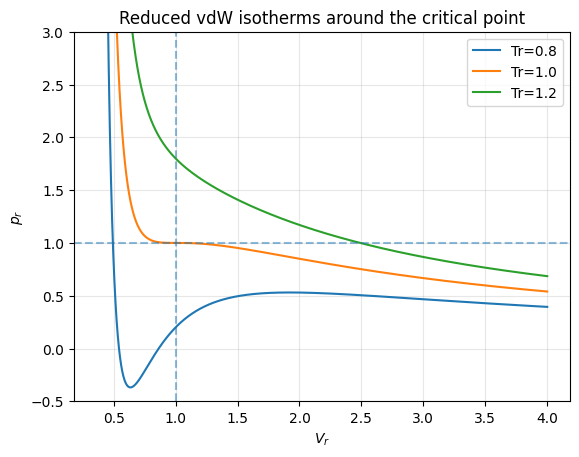

In [28]:
gas='CO2'
Vc,pc,Tc,Zc=vdw_critical(gas)
Vr=np.linspace(0.36,4,2000)
for Tr in [0.8,1.0,1.2]:
    plt.plot(Vr,pr_vdw(Vr,Tr),label=f'Tr={Tr}')
plt.axhline(1,linestyle='--',alpha=0.5)
plt.axvline(1,linestyle='--',alpha=0.5)
plt.xlabel('$V_r$')
plt.ylabel('$p_r$')
plt.ylim(-0.5,3)
plt.title('Reduced vdW isotherms around the critical point')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


- 임계 온도 아래 ($T_r = 0.8$ - 파란색 곡선):임계점보다 낮은 저온 상태의 등온선으로, 압력이 증가하다가 요동치는 형태(물결 모양 영역)가 나타납니다.
이 구간에서는 기체가 액화될 수 있으며, 실제 물리계에서는 상전이에 의해 압력이 일정한 수평선으로 나타나게 됩니다.
- 임계 온도 ($T_r = 1.0$ - 주황색 곡선):임계점($p_r = 1, V_r = 1$)을 정확히 통과하는 등온선입니다.
변곡점에서 기울기가 0이 되며, 기체상과 액체상의 구분이 사라지는 임계 현상(인플렉션 포인트)을 명확하게 보여줍니다.
- 임계 온도 위 ($T_r = 1.2$ - 초록색 곡선):임계 온도보다 충분히 높은 고온 상태의 등온선으로, 요동치는 구간 없이 매끄러운 단조 감소 곡선을 그립니다.
압력을 아무리 높여도 액화되지 않고 초임계 유체나 기체 상태를 유지하는 성상을 보여줍니다.

# 대응상태 원리

> **PPT 연계:** p.29–30

환산변수:

$$V_r=\frac{V_m}{V_c},\qquad p_r=\frac{p}{p_c},\qquad T_r=\frac{T}{T_c}$$

van der Waals 식은

$$p_r=\frac{8T_r}{3V_r-1}-\frac{3}{V_r^2}$$

이 되어 $a,b$가 사라집니다.

따라서 기체의 종류(Ar, CO$_2$, He, Xe 등)가 달라도 동일한 환산 온도($T_r$)와 환산 부피($V_r$)를 가지면 정확히 동일한 환산 압력($p_r$)을 나타낸다는 보편성을 보여줍니다.


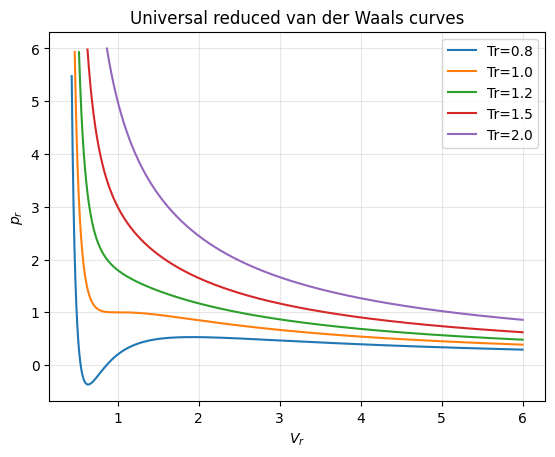

In [29]:
Vr=np.linspace(0.38,6,1500)
for Tr in [0.8,1.0,1.2,1.5,2.0]:
    pr=pr_vdw(Vr,Tr)
    mask=(pr>-0.5)&(pr<6)
    plt.plot(Vr[mask],pr[mask],label=f'Tr={Tr}')
plt.xlabel('$V_r$')
plt.ylabel('$p_r$')
plt.title('Universal reduced van der Waals curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [30]:
# 실제 a,b가 다른 네 기체를 같은 reduced state에 놓고 p를 계산해 비교
Tr=1.5
Vr=2.0
rows=[]
for gas in vdw:
    Vc,pc,Tc,Zc=vdw_critical(gas)
    T=Tr*Tc
    Vm=Vr*Vc
    p_atm=vdw_p_bar(Vm,T,gas)/1.01325
    rows.append([gas,T,Vm,p_atm,p_atm/pc])
df=pd.DataFrame(rows,columns=['gas','T/K','Vm/L mol^-1','p/atm','p_r'])
display(df)
print('동일한 Tr, Vr에서 p_r가 거의 동일한지 확인하세요.')


,gas,T/K,Vm/L mol^-1,p/atm,p_r
0,Ar,226.298324,0.1920,79.790582,1.65
1,CO2,455.774286,0.2574,119.870633,1.65
2,He,7.760279,0.1428,3.678923,1.65
3,Xe,434.245902,0.3096,94.952477,1.65


동일한 Tr, Vr에서 p_r가 거의 동일한지 확인하세요.


# 통합 프로젝트 — 가상 기체 실험실

이 프로젝트는 한 번에 네 가지를 연결합니다.

1. Maxwell–Boltzmann 속력 분포
2. 대표 속력
3. 충돌빈도/평균 자유 행로
4. van der Waals 압축인자 $Z$




In [ ]:
def virtual_gas_lab(gas='CO2', T=300, p_atm=10.0):
    M=molar_mass_gmol[gas]/1000
    vmp=np.sqrt(2*R*T/M)
    vmean=np.sqrt(8*R*T/(np.pi*M))
    vrms=np.sqrt(3*R*T/M)
    print(f'=== {gas} at {T:.1f} K, {p_atm:.2f} atm ===')
    print(f'v_mp={vmp:.1f}, v_mean={vmean:.1f}, v_rms={vrms:.1f} m/s')

    if gas in collision_sigma_nm2:
        sigma=collision_sigma_nm2[gas]*1e-18
        vrel=np.sqrt(2)*vmean
        z=sigma*vrel*(p_atm*ATM_PA)/(kB*T)
        lam=kB*T/(sigma*p_atm*ATM_PA)
        print(f'z={z:.3e} s^-1, lambda={lam*1e9:.2f} nm')
    else:
        print('collision cross-section: PPT table에 없음')

    if gas in vdw:
        Z,Vm=vdw_Z_gas_branch(gas,T,p_atm)
        print(f'vdW gas-branch Vm={Vm:.4f} L/mol, Z={Z:.4f}')
        if Z<0.98: print('→ attraction-dominant nonideality direction')
        elif Z>1.02: print('→ repulsion/excluded-volume direction')
        else: print('→ near-ideal in this metric')
    else:
        print('vdW a,b: PPT table에 없음')

    vmax=max(1200,4*vrms)
    v=np.linspace(0,vmax,1200)
    plt.plot(v,maxwell_speed_pdf(v,M,T))
    plt.axvline(vmp,linestyle=':',label='v_mp')
    plt.axvline(vmean,linestyle='--',label='v_mean')
    plt.axvline(vrms,linestyle='-.',label='v_rms')
    plt.xlabel('v / m s$^{-1}$')
    plt.ylabel('f(v)')
    plt.title(f'{gas}: molecular speed distribution')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

if WIDGETS_OK:
    interact(virtual_gas_lab,
             gas=widgets.Dropdown(options=['He','N2','CO2','Xe','Ar'],value='CO2'),
             T=widgets.IntSlider(value=300,min=100,max=1000,step=20),
             p_atm=widgets.FloatLogSlider(value=10,min=-1,max=2.3,step=0.1,description='p/atm'));
else:
    virtual_gas_lab()
